# Demo: Arrow-Pratt Risk Aversion Measures
The curvature of a decision-maker's utility over wealth sets their attitude toward risk. The __Arrow-Pratt__ measures turn that curvature into a number. This example computes the coefficient of absolute risk aversion and the coefficient of relative risk aversion for three wealth utilities, logarithmic, linear, and power, and uses them to classify each as risk averse, risk neutral, or risk seeking.

> __Learning Objectives.__
>
> This example computes risk-aversion measures from a utility function and interprets them:
> * __Absolute and relative risk aversion:__ Compute the Arrow-Pratt coefficients $A(w)=-U''(w)/U'(w)$ and $R(w)=w\,A(w)$ for a wealth utility $U(w)$.
> * __Automatic differentiation:__ Obtain $U'(w)$ and $U''(w)$ by automatic differentiation and confirm the results match the closed-form measures.
> * __Risk attitude classification:__ Use the sign of $A(w)$ to classify a utility as risk averse ($A>0$), risk neutral ($A=0$), or risk seeking ($A<0$).

Let's get started.
___

## Theory
Let $U:\mathbb{R}_{+}\rightarrow\mathbb{R}$ be a twice-differentiable utility over wealth $w$. The __Arrow-Pratt coefficient of absolute risk aversion__ is
$$
A(w) = -\frac{U''(w)}{U'(w)},
$$
and the __coefficient of relative risk aversion__ is
$$
R(w) = -\,w\,\frac{U''(w)}{U'(w)} = w\,A(w).
$$
Assume $U'(w)>0$ (utility increases with wealth). The sign of $A(w)$ classifies the decision-maker:

| Curvature of $U$ | $A(w)$ | Risk attitude |
| :--- | :--- | :--- |
| $U''<0$ (concave) | $A(w)>0$ | risk averse |
| $U''=0$ (linear) | $A(w)=0$ | risk neutral |
| $U''>0$ (convex) | $A(w)<0$ | risk seeking |

We compute $A(w)$ and $R(w)$ for the three utilities below. The derivatives $U'(w)$ and $U''(w)$ are obtained by automatic differentiation, so the same `absolute_risk_aversion(...)` and `relative_risk_aversion(...)` code works for any twice-differentiable utility; we confirm the results against these closed forms:

| Utility | $U(w)$ | $A(w)$ | $R(w)$ |
| :--- | :--- | :--- | :--- |
| Logarithmic | $\ln w$ | $1/w$ | $1$ |
| Linear | $a w + b$ | $0$ | $0$ |
| Power | $w^{\tau}$ | $(1-\tau)/w$ | $1-\tau$ |
___

## Setup
This example uses functions defined in the `src` directory and a small set of external packages. The `include(...)` call below runs `Include.jl`, which activates the local project environment, loads the packages, and includes our code. The first run may take a few minutes while packages are installed and precompiled.

In [1]:
include("Include.jl");

  Activating project at `~/Desktop/julia_work/CHEME-140-eCornell-Repository/courses/CHEME-145/module-1`


## Wealth Grid
We evaluate the risk measures over a range of wealth values $w$.

In [2]:
w = range(1.0, stop = 10.0, length = 100) |> collect;

## Logarithmic Utility: Risk Averse
The logarithmic utility $U(w)=\ln w$ has $U'(w)=1/w>0$ and $U''(w)=-1/w^{2}<0$, so
$$
A(w) = -\frac{-1/w^{2}}{1/w} = \frac{1}{w} > 0,\qquad R(w) = w\,A(w) = 1.
$$
Absolute risk aversion is positive for all wealth (risk averse) and decreases as wealth grows, while relative risk aversion is constant at 1. We compute and plot $A(w)$ for the logarithmic utility next.

isapprox(A_log, 1 ./ w, atol = 1.0e-8) = true


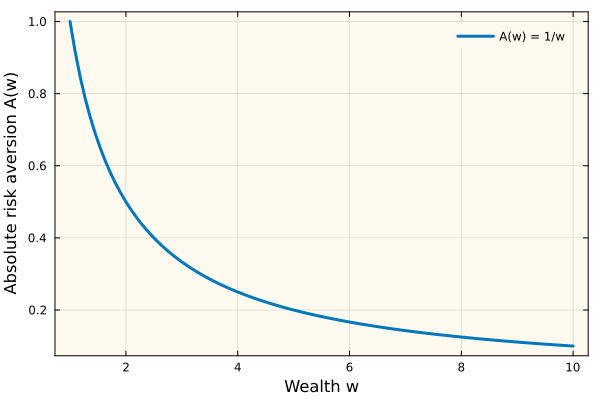

In [3]:
let
    log_utility = build(MyLogarithmicUtilityFunction);

    # A(w) by automatic differentiation; confirm it matches the closed form 1/w -
    A_log = absolute_risk_aversion.(Ref(log_utility), w);
    @show isapprox(A_log, 1 ./ w, atol = 1e-8);

    plot(w, A_log, label = "A(w) = 1/w", lw = 3, c = colors[1],
        bg = "floralwhite", background_color_outside = "white", framestyle = :box, fg_legend = :transparent);
    xlabel!("Wealth w");
    ylabel!("Absolute risk aversion A(w)");
    current()
end

## Linear Utility: Risk Neutral
The linear utility $U(w)=a w+b$ has $U'(w)=a$ and $U''(w)=0$, so $A(w)=0$ and $R(w)=0$ for all wealth: the decision-maker is risk neutral and ranks lotteries by expected wealth alone. We compute and plot $A(w)$ for the linear utility next.

isapprox(A_linear, zeros(length(w)), atol = 1.0e-8) = true


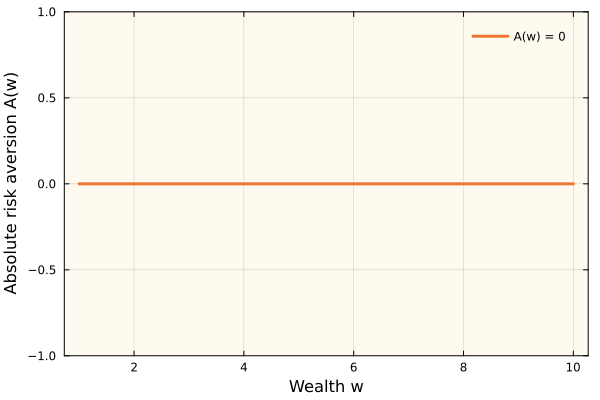

In [4]:
let
    linear_utility = build(MyLinearWealthUtilityFunction, (a = 2.0, b = 1.0));

    A_linear = absolute_risk_aversion.(Ref(linear_utility), w);
    @show isapprox(A_linear, zeros(length(w)), atol = 1e-8);

    plot(w, A_linear, label = "A(w) = 0", lw = 3, c = colors[3],
        bg = "floralwhite", background_color_outside = "white", framestyle = :box,
        fg_legend = :transparent, ylims = (-1.0, 1.0));
    xlabel!("Wealth w");
    ylabel!("Absolute risk aversion A(w)");
    current()
end

## Power Utility: All Three Attitudes
The power utility $U(w)=w^{\tau}$ has $U'(w)=\tau w^{\tau-1}$ and $U''(w)=\tau(\tau-1)w^{\tau-2}$, so
$$
A(w) = \frac{1-\tau}{w},\qquad R(w) = 1-\tau.
$$
The exponent $\tau$ sets the attitude: $\tau<1$ is risk averse ($A>0$), $\tau=1$ is risk neutral ($A=0$, the linear case), and $\tau>1$ is risk seeking ($A<0$). Relative risk aversion $R(w)=1-\tau$ is constant in wealth (constant relative risk aversion). We plot $A(w)$ for one value of each type.

isapprox(A_power, (1 .- τ) ./ w, atol = 1.0e-8) = true
isapprox(A_power, (1 .- τ) ./ w, atol = 1.0e-8) = true
isapprox(A_power, (1 .- τ) ./ w, atol = 1.0e-8) = true


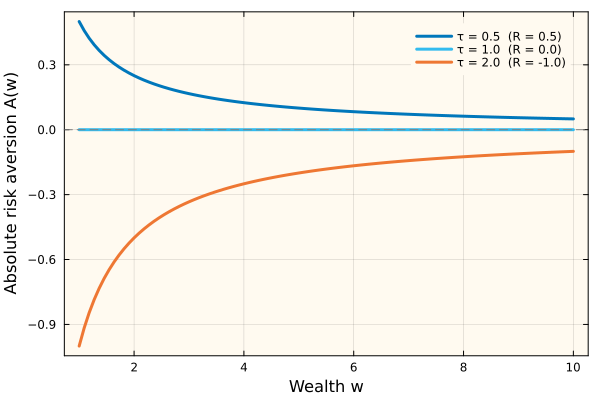

In [5]:
let
    taus = [0.5, 1.0, 2.0];   # risk averse, risk neutral, risk seeking
    plt = plot();
    for (i, τ) ∈ enumerate(taus)
        power_utility = build(MyPowerUtilityFunction, (τ = τ,));
        A_power = absolute_risk_aversion.(Ref(power_utility), w);
        @show isapprox(A_power, (1 .- τ) ./ w, atol = 1e-8);
        plot!(plt, w, A_power, label = "τ = $(τ)  (R = $(round(1 - τ, digits = 2)))", lw = 3, c = colors[i],
            bg = "floralwhite", background_color_outside = "white", framestyle = :box, fg_legend = :transparent);
    end
    hline!(plt, [0.0], label = "", c = :gray, ls = :dash);
    xlabel!(plt, "Wealth w");
    ylabel!(plt, "Absolute risk aversion A(w)");
    current()
end

## Summary
This example computed the Arrow-Pratt measures of absolute and relative risk aversion for logarithmic, linear, and power wealth utilities, obtaining the derivatives by automatic differentiation and confirming them against the closed forms. The sign of $A(w)$ classifies the risk attitude.

> __Key takeaways:__
>
> 1. **Curvature is risk aversion:** The Arrow-Pratt coefficient $A(w)=-U''(w)/U'(w)$ measures the curvature of the utility, and its sign classifies the decision-maker as risk averse ($A>0$), risk neutral ($A=0$), or risk seeking ($A<0$).
> 2. **Absolute and relative measures differ:** Logarithmic utility has decreasing absolute risk aversion $A(w)=1/w$ but constant relative risk aversion $R(w)=1$; power utility $w^{\tau}$ has constant relative risk aversion $R(w)=1-\tau$.
> 3. **One computation, any utility:** Automatic differentiation gives $U'$ and $U''$, so a single `absolute_risk_aversion(...)` function returns the measure for any twice-differentiable utility.

The Arrow-Pratt measures summarize risk attitude at a point; the insurance example uses a full utility function to make a risk decision, computing the certainty equivalent and risk premium.
___

### Additional Resources
* Pratt, J. W. (1964). Risk aversion in the small and in the large. _Econometrica_, 32(1/2), 122–136.
* Arrow, K. J. (1971). _Essays in the Theory of Risk-Bearing_. Markham.
* Mas-Colell, A., Whinston, M. D., & Green, J. R. (1995). _Microeconomic Theory_. Oxford University Press.